# Overfitting and Underfitting

This notebook fits polynomial regressions of increasing degree to a noisy sine wave, showing underfitting, a good fit and overfitting through train and test RMSE.

## Import Required Libraries

Import numpy, matplotlib and the scikit-learn polynomial tools.

In [1]:
# Import the required libraries.
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Define the course colour palette.
colors = ["#179E86", "#2580B7", "#9EBE5B", "#C03B26", "#44546A"]

## Generate a Noisy Sine Wave

Sample points from a sine function and add Gaussian noise, then split into train and test.

In [2]:
# Generate noisy samples from a sine function.
np.random.seed(42)

def true_fn(x):
    return np.sin(2 * np.pi * x)

n = 60
x = np.sort(np.random.rand(n))
noise = np.random.normal(0, 0.2, size=n)
y = true_fn(x) + noise

# Split into train and test sets.
idx = np.random.permutation(n)
train_idx, test_idx = idx[:40], idx[40:]
x_train, y_train = x[train_idx], y[train_idx]
x_test, y_test = x[test_idx], y[test_idx]
print(f"Train: {len(x_train)}, Test: {len(x_test)}")

Train: 40, Test: 20


## Fitting Four Polynomial Degrees

Degrees 1, 3, 9 and 15 span from underfitting to overfitting; we record the train and test RMSE of each.

In [3]:
# Fit polynomial models of several degrees and store RMSE.
degrees = [1, 3, 9, 15]
x_grid = np.linspace(0, 1, 300)
results = {}
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d),
                          LinearRegression())
    model.fit(x_train[:, None], y_train)
    tr = np.sqrt(mean_squared_error(
        y_train, model.predict(x_train[:, None])))
    te = np.sqrt(mean_squared_error(
        y_test, model.predict(x_test[:, None])))
    curve = model.predict(x_grid[:, None])
    results[d] = {"train": tr, "test": te, "curve": curve}
print("RMSE recorded for degrees:", degrees)

RMSE recorded for degrees: [1, 3, 9, 15]


## A 2x2 Grid of Fits

Each panel overlays the fitted polynomial on the data with its train and test RMSE in the title.

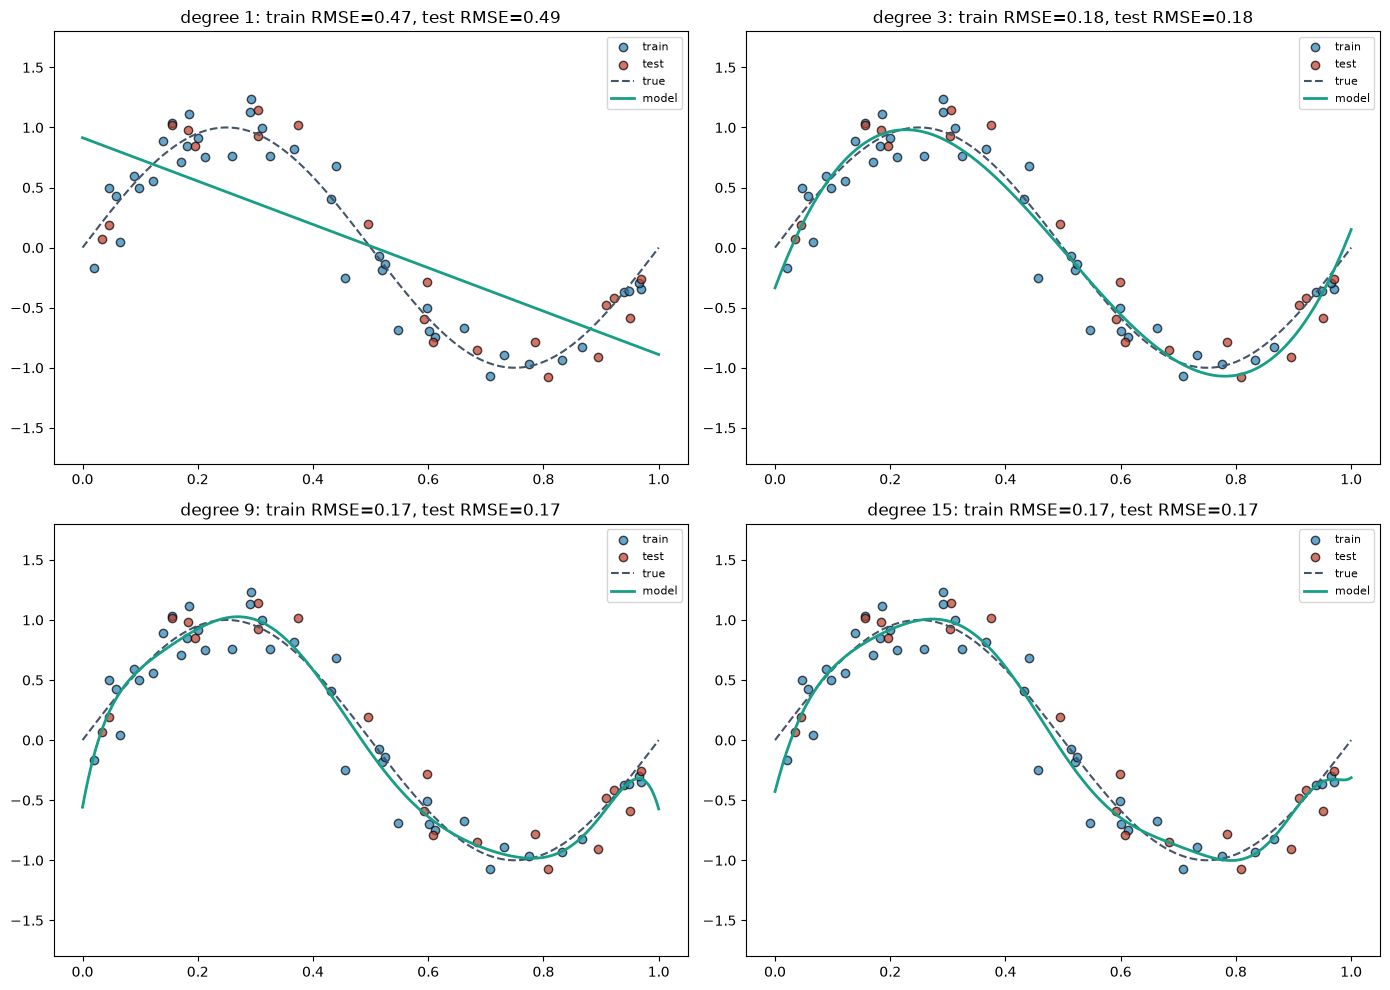

In [4]:
# Plot the four fitted polynomials in a 2x2 grid.
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, d in zip(axes.ravel(), degrees):
    ax.scatter(x_train, y_train, color=colors[1],
               edgecolor="k", alpha=0.7, label="train")
    ax.scatter(x_test, y_test, color=colors[3],
               edgecolor="k", alpha=0.7, label="test")
    ax.plot(x_grid, true_fn(x_grid), color=colors[4],
            linestyle="--", label="true")
    ax.plot(x_grid, results[d]["curve"], color=colors[0],
            linewidth=2, label="model")
    ax.set_ylim(-1.8, 1.8)
    ax.set_title(f"degree {d}: train RMSE="
                 f"{results[d]['train']:.2f}, test RMSE="
                 f"{results[d]['test']:.2f}")
    ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## The U-Shaped Test Error

Sweeping every degree from 1 to 15 reveals the characteristic U shape of test error against complexity.

In [5]:
# Compute train and test RMSE for every degree up to 15.
all_degrees = range(1, 16)
train_rmse, test_rmse = [], []
for d in all_degrees:
    model = make_pipeline(PolynomialFeatures(d),
                          LinearRegression())
    model.fit(x_train[:, None], y_train)
    train_rmse.append(np.sqrt(mean_squared_error(
        y_train, model.predict(x_train[:, None]))))
    test_rmse.append(np.sqrt(mean_squared_error(
        y_test, model.predict(x_test[:, None]))))

best_degree = list(all_degrees)[int(np.argmin(test_rmse))]
print(f"Degree with lowest test RMSE: {best_degree}")

Degree with lowest test RMSE: 11


## Plotting RMSE vs Degree

The training RMSE decreases monotonically while the test RMSE falls, reaches a minimum and rises again.

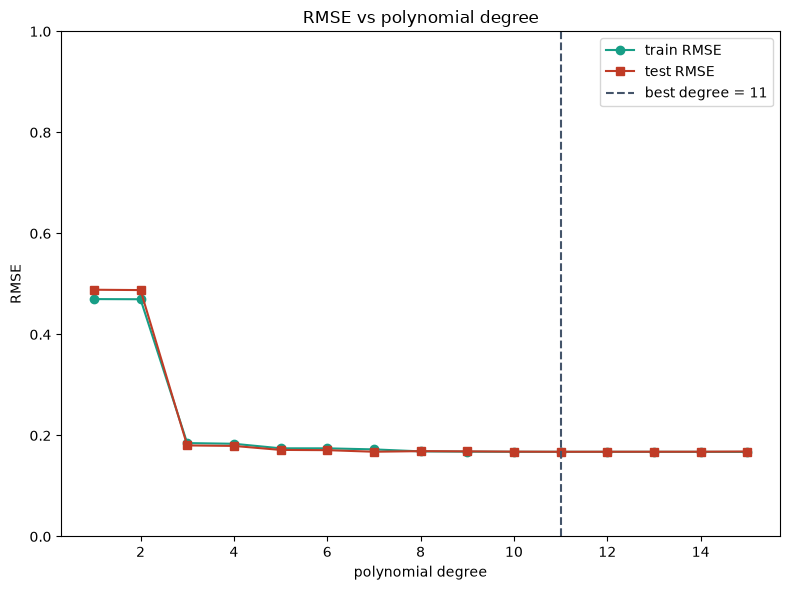

In [6]:
# Plot RMSE against polynomial degree.
plt.figure(figsize=(8, 6))
plt.plot(list(all_degrees), train_rmse, marker="o",
         color=colors[0], label="train RMSE")
plt.plot(list(all_degrees), test_rmse, marker="s",
         color=colors[3], label="test RMSE")
plt.axvline(best_degree, color=colors[4], linestyle="--",
            label=f"best degree = {best_degree}")
plt.ylim(0, 1.0)
plt.title("RMSE vs polynomial degree")
plt.xlabel("polynomial degree")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()

## Summary

- **Underfitting**: low-degree models miss the sine shape (high train and test error).
- **Good fit**: a moderate degree matches the true function.
- **Overfitting**: high-degree models chase noise (low train, high test error).
- **U shape**: test error is minimised at an intermediate complexity.